Написати додаток, який отримує вибірку впорядкованих пар. Кожна пара розміщена на новій строці. Перевірити чи існує кореляція між значеннями пар. Та зайти графік лінійної регресії для вказаної перевірки. Побудувати коефіцієнт детермінації, для графіка регресії, що знайдено.

In [39]:
import pandas as pd
import math
import matplotlib.pyplot as plt

In [40]:
# alpha = 0.05

In [41]:
# df = pd.read_csv("./data/imdb_data.csv")

# year = df["Year"]
# rating = df["Rating"]

In [42]:
# year_mean = year.mean()
# rating_mean = rating.mean()

# # r = Σ((x - x̄)(y - ȳ)) / sqrt(Σ(x - x̄)^2 * Σ(y - ȳ)^2)

# numerator = ((year - year_mean) * (rating - rating_mean)).sum()

# sum_sq_year = ((year - year_mean)**2).sum()
# sum_sq_rating = ((rating - rating_mean)**2).sum()

# denominator = math.sqrt(sum_sq_year * sum_sq_rating)

# r = numerator / denominator

# print(f"Коефіцієнт кореляції r: {r:.4f}")

# # b1 = Σ((x - x̄)(y - ȳ)) / Σ((x - x̄)^2)
# # b0 = ȳ - b1*x̄

# b1 = numerator / sum_sq_year
# b0 = year_mean - b1 * rating_mean

# print(f"Рівняння регресії: y = {b0:.2f} + {b1:.2f}x")

# # R² = r²
# R2 = r**2
# print(f"Коефіцієнт детермінації (R²): {R2:.4f}")



In [43]:
# # -------- 4. Побудова графіка --------
# plt.figure(figsize=(8,6))
# plt.scatter(year_mean, rating_mean, color='blue', label='Дані')
# plt.plot(year_mean, b0 + b1*year_mean, color='red', label='Лінія регресії')
# plt.xlabel("Sleep Hours")
# plt.ylabel("Exam Score")
# plt.title("Регресія: Sleep Hours vs Exam Score (все руками)")
# plt.legend()
# plt.grid(True)
# plt.show()

Коефіцієнт кореляції r: 0.0457
Рівняння регресії: y = 7.4925 + 0.0004x
Коефіцієнт детермінації (R²): 0.0021

Побудова графіка...


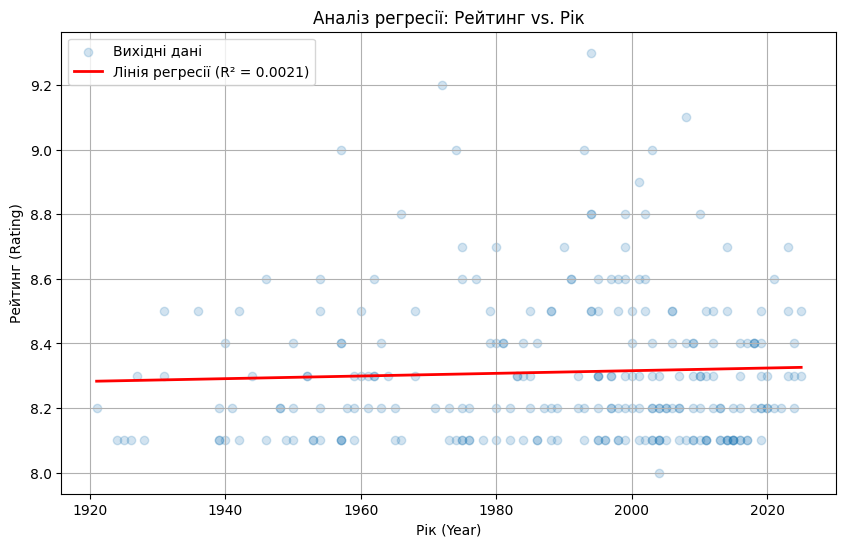

In [44]:
import pandas as pd
import math
import matplotlib.pyplot as plt  # Додано для візуалізації

alpha = 0.05

try:
    df = pd.read_csv("./data/imdb_data.csv")
except FileNotFoundError:
    print("Помилка: Файл './data/imdb_data.csv' не знайдено.")
    exit()

year = df["Year"]
rating = df["Rating"]

year_mean = year.mean()
rating_mean = rating.mean()

# -------- 1. Кореляція (r) --------
# r = Σ((x - x̄)(y - ȳ)) / sqrt(Σ(x - x̄)^2 * Σ(y - ȳ)^2)

numerator = ((year - year_mean) * (rating - rating_mean)).sum()

sum_sq_year = ((year - year_mean)**2).sum()
sum_sq_rating = ((rating - rating_mean)**2).sum()

denominator = math.sqrt(sum_sq_year * sum_sq_rating)

r = 0.0
if denominator != 0:
    r = numerator / denominator

print(f"Коефіцієнт кореляції r: {r:.4f}")

# -------- 2. Лінійна регресія (b0, b1) --------
# b1 = Σ((x - x̄)(y - ȳ)) / Σ((x - x̄)^2)
# b0 = ȳ - b1*x̄

b1 = 0.0
if sum_sq_year != 0:
    b1 = numerator / sum_sq_year

# --- !!! ВИПРАВЛЕННЯ ТУТ !!! ---
# Стара помилкова строка: b0 = year_mean / b1 * rating_mean
b0 = rating_mean - b1 * year_mean  # Правильна формула

print(f"Рівняння регресії: y = {b0:.4f} + {b1:.4f}x")

# -------- 3. Коефіцієнт детермінації (R²) --------
# R² = r²
R2 = r**2
print(f"Коефіцієнт детермінації (R²): {R2:.4f}")


# -------- 4. Побудова графіка --------
print("\nПобудова графіка...")

plt.figure(figsize=(10, 6))
# Діаграма розсіювання
plt.scatter(year, rating, alpha=0.2, label='Вихідні дані')

# Лінія регресії
x_line = [year.min(), year.max()]
y_line = [b0 + b1 * x_val for x_val in x_line]
plt.plot(x_line, y_line, color='red', linewidth=2, 
         label=f'Лінія регресії (R² = {R2:.4f})')

plt.title('Аналіз регресії: Рейтинг vs. Рік')
plt.xlabel('Рік (Year)')
plt.ylabel('Рейтинг (Rating)')
plt.legend()
plt.grid(True)
plt.show()